## <img src="logo_UNSAM.jpg" align="right" width="300" height="300"> *Análisis y precesamiento de señales*  
<h3 style="font-weight: normal;">Alumno: Joaquín Rios</h3>
&nbsp;
&nbsp;

# |  Trabajo Semanal N°5

### | Introducción

&emsp; En este trabajo vamos a aplicar distintos métodos de estimación de la **densidad espectral de potencia (PSD)** sobre señales reales, con el objetivo de analizar su contenido frecuencial y caracterizar su ancho de banda. Para ello se trabajará con tres tipos de señales: un *electrocardiograma (ECG)*, un  *pletismografía (PPG)* y *una señal de audio* , obtenidas de los registros disponibles en el repositorio PDStestbench. A diferencia de los trabajos anteriores, donde se trabajó principalmente con señales jueguete y parámetros conocidos, en este caso analizaremos señales provenientes de mediciones reales, por lo que la estimación de su contenido espectral es fundamental para poder caracterizarlas.

&emsp; Para cada señal se estimará su PSD utilizando alguno de los siguientes métodos: periodograma ventaneado, método de Welch o método de Blackman-Tukey. El periodograma ventaneado se expresa como:

$$ \hat{S}_{xx}(f)=\frac{1}{NU}\left|\sum_{n=0}^{N-1}x[n]w[n]e^{-j2\pi fn}\right|^2 $$

donde $N$ es la cantidad de muestras del registro y $U$ es el factor de normalización asociado a la ventana, y donde básicamente estamos haciendo un promedio de todas las muestras implementando una ventana en la señal.

&emsp; Para el método de Welch, la señal se divide en $M$ segmentos de $N$ muestras, generalmente con solapamiento, calculándose un periodograma para cada segmento y promediándolos:

$$ \hat{S}_{W}(f)=\frac{1}{M}\sum_{i=1}^{M}\hat{S}_{i}(f) $$

donde $M$ es la cantidad de segmentos en los que se divide la señal y $N$ es la cantidad de muestras de cada segmento. En este caso se utilizará un solapamiento del $50$ %.

  Por otro lado, el método de Blackman-Tukey estima la PSD a partir de la autocorrelación de la señal:
  
$$ \hat{S}_{BT}(f)=\sum_{k=-M}^{M}\hat{R}_{xx}[k]w[k]e^{-j2\pi fk} $$

donde $M$ determina la cantidad de retardos de la autocorrelación que se utilizan.

### | Desarrollo Experimental
#### | Electrocardiograma
&emsp; Arrancamos analizando el *electrocardiograma (ECG)* eligiendo alguno de los métodos vistos anteriormente, en este caso usaremos el método de Welch, y para esto utilizaremos distintas longitudes de **L** para ver qué sucede, estas L serán proporcionales a la cantidad de muestras que tengamos, y se observarán 4 valores distintos en una misma figura. 
##### | Estimación de la Densidad Espectral de Potencia (DEP)

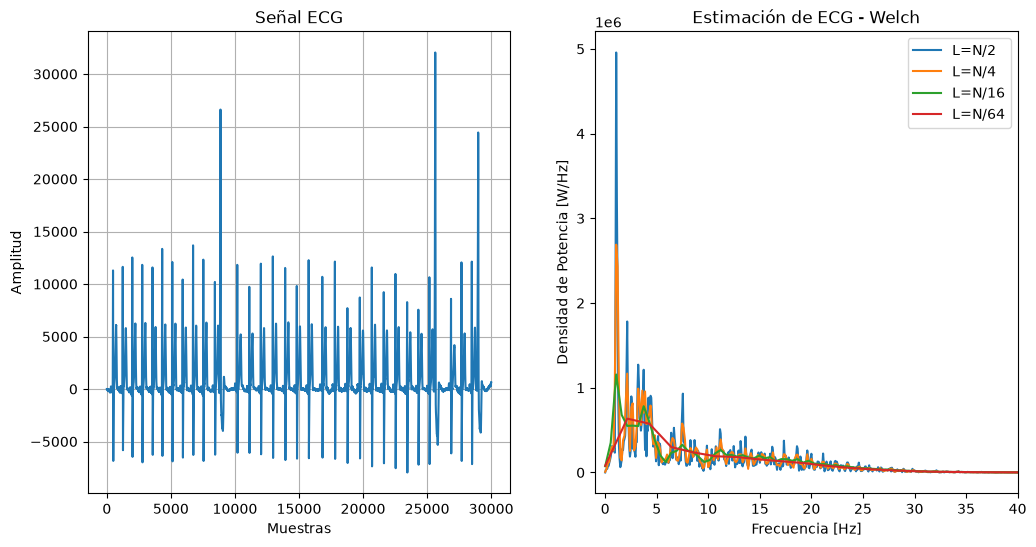

In [10]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import square, unit_impulse
from scipy.fft import fft,  fftfreq

import scipy.io as sio
from scipy.io.wavfile import write

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

#%%Definiciones
N = 1000
fs = 1000

##################
# Lectura de ECG #
##################

fs_ECG = 1000 # Hz

##################
## ECG sin ruido#
##################

ECG = np.load('ecg_sin_ruido.npy')

ax1.set_title('Señal ECG')
ax1.set_xlabel('Muestras')
ax1.set_ylabel('Amplitud')
ax1.plot(ECG)
ax1.grid(True)

NE = len(ECG)
#%%
frec, DEP_ECG_welch = signal.welch(ECG,fs=fs_ECG,nperseg=(max(1, NE//2))) #nperseg mide la longitud de cada periodograma para calcular la DEP 
frec2, DEP_PPG_welch2 = signal.welch(ECG, fs=fs_ECG, nperseg=max(1, NE//4))
frec3, DEP_PPG_welch3 = signal.welch(ECG, fs=fs_ECG, nperseg=max(1, NE//16))
frec4, DEP_PPG_welch4 = signal.welch(ECG, fs=fs_ECG, nperseg=max(1, NE//64))

ax2.set_title('Estimación de ECG - Welch')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('Densidad de Potencia [W/Hz]')
ax2.plot(frec,DEP_ECG_welch, label = "L=N/2")
ax2.plot(frec2,DEP_PPG_welch2, label = "L=N/4")
ax2.plot(frec3,DEP_PPG_welch3, label = "L=N/16")
ax2.plot(frec4,DEP_PPG_welch4, label = "L=N/64")
ax2.set_xlim(-1, 40)
ax2.legend()

plt.show()


&emsp; Primero hay que notar dos cuestiones importante, al estar promediando con un L cada vez más pequeño, por la relación $ Δf ≈  \frac{fs}{L}$ notamos que la resolución espectral empeora al bajar L. Por otro lado se acortó el eje X para que la señal se vea mejor en la figura, ya que luego de este valor la señal se mueve asintóticamente a 0.

&emsp; Analizando las 4 sesñales construidas a partir del ECG, notamos que, al aumentar la longitud de cada bloque de periodograma, el "pico" más alto de cada señal cae, esto se asocia directamente con el aumento del valor de resolución espectral, lo que provoca dos fenómenos diferentes, por un lado aumenta el sesgo de las muestras debido al ensanchamiento del lóbulo principal de la ventana utilizada, que en este caso en la $han$ por defecto en la función **signal.welch**, lo que induce un pico más bajo al estar tomando tal vez valores negativos incluso de la señal. En contraparte de este efecto, vemos como baja drásticamente la varianza de la señal, ya que esta es inversamente proporcional a $\frac{N}{L}$, la curva roja se la ve más suave. Parece que para representar bien la densidad espectral de potencia, a pesar de tener una varianza considerable, debemos mantener un L de bajo valor, ya que así podemos ver los armónicos fundamentales para representar bien la sañel original. Estos resultados se corroborarán de acuerdo a lo presentado en la siguente señal.

##### | Estimación del Ancho de Banda de la señal
&emsp; Para estimar el ancho de banda primero debemos establecer un criterio adecuado para esto, ya que sino podríamos tomar un ancho de banda para frecuencias que no aportan verdaderamente a la señal, por lo que se decidió que este debe contener el **99%** de la potencia de la señal.